In [91]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [92]:
import os
os.listdir()

['.ipynb_checkpoints',
 'analyze_exoplanet_data.ipynb',
 'car_crashes.csv',
 'exoplanet_data.csv',
 'homework8.ipynb',
 'hw8_branch1.png',
 'hw8_branch2.png',
 'hw8_branch3.png',
 'state_data.csv']

In [93]:
df = pd.read_csv("exoplanet_data.csv", comment = "#")

In [94]:
df.shape

(570, 92)

In [95]:
# this dataset is shaped (570, 92)
# this dataset has 570 rows and 92 columns
print(df.columns)
# The following are 5 out of 92 titles I don't understand
# sy_gaiamag
# pl_pubdate
# pl_insollim
# ttv_flag
# rastr

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [96]:
# Planet Name
# pl_name
# Planet name most commonly used in the literature
# I think it is the term we use to refer to the planet

In [97]:
# Host Name
# hostname
# Stellar name most commonly used in the literature
# I think it's the name of the star the planet orbits

In [98]:
# Discovery Method
# discoverymethod
# Method by which the planet was first identified
# Technique used to find the planet

In [99]:
# Spectral Type
# st_spectype
# Classification of the star based on their spectral characteristics
# following the Morgan-Keenan system
# I think it's the type of star based on the wavelengths it emits

In [100]:
# Equilibrium Temperature
# pl_eqt
# The equilibrium temperature of the planet as modeled by a black body
# heated only by its host star, or for directly imaged planets, the
# effective temperature of the planet required to match the measured
# luminosity if the planet were a black body
# I think it's the estimated temperature of the planet based on the host's
# radiation

In [101]:
# Planet Mass or Mass*sin(i) [Jupiter Mass]
# pl_bmassj
# Best planet mass estimate available, in order of preference: 
# Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability,
# and measured in Jupiter massesed mass based on the planet's
# motion
# Planet's mass in terms of Jupiter's mass,according to best estimate

In [102]:
columns_of_interest = ["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]
new_df = df[columns_of_interest]
print(new_df)

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
0        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.912000
1        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.870000
2       DMPP-1 b     DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3       DMPP-1 c     DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4       DMPP-1 d     DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
..           ...        ...              ...         ...     ...        ...
565    bet Pic c    bet Pic  Radial Velocity         NaN  1250.0   8.200000
566    bet Pic c    bet Pic  Radial Velocity         NaN     NaN  10.139000
567    bet Pic c    bet Pic  Radial Velocity         NaN     NaN   9.000000
568  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0   6.310000
569  eps Ind A b  eps Ind A  Radial Velocity        K2 V     NaN   3.250000

[570 rows x 6 columns]


In [103]:
clean_df = new_df.dropna()

In [104]:
clean_df.shape

(67, 6)

In [105]:
# The smaller dataset is shaped like (67, 6)
# It has 67 rows and 6 columns

In [106]:
print(clean_df.head())

    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000


In [107]:
print(clean_df.tail())

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
549   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
551   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
555   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
562       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
568  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310


In [108]:
print(clean_df.columns)

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [109]:
print(clean_df["discoverymethod"].value_counts())

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


In [110]:
# The three discovery methods were transit, radial velocity, and imaging
# 52 were discovered using transit methods (most)
# 13 were discovered using radial velocity methods
# 2 were discovered using imaging methods (least)

In [111]:
# Transit: luminosity dips from host star as planet passes in front
# Radial velocity: uses Doppler shifts to detect host star's motion from planet's gravity
# Imaging: straight up taking a picture of the planet by filtering out glare from host

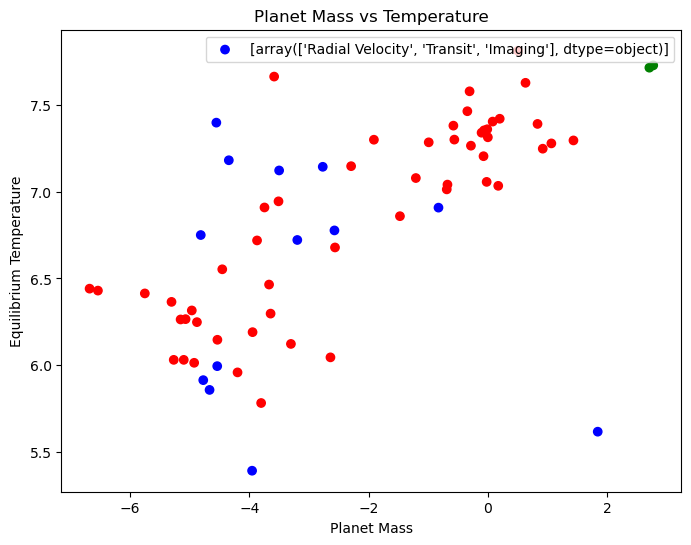

In [112]:
plt.figure(figsize = (8, 6))
methods = clean_df["discoverymethod"]
colormap = {"Transit": "r",
            "Radial Velocity": "b",
            "Imaging": "g"}
colors = [colormap[method] for method in methods]
labels = [clean_df["discoverymethod"].unique()]
plt.scatter(np.log(clean_df["pl_bmassj"]), np.log(clean_df["pl_eqt"]), c = colors, label = labels)
plt.xlabel("Planet Mass")
plt.ylabel("Equilibrium Temperature")
plt.title("Planet Mass vs Temperature")
plt.legend()
plt.show()

In [113]:
# The imaging planets are likely to be very massive

In [114]:
big = clean_df[clean_df["pl_bmassj"] > 5]
cold = big["pl_eqt"].min()
cold_info = big[big["pl_eqt"] == cold]

In [115]:
print(cold_info)

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
568  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0       6.31


In [116]:
print(cold_info["pl_name"])
# It's name is eps Ind A b

568    eps Ind A b
Name: pl_name, dtype: object


In [117]:
print("Index: ", big["pl_eqt"].idxmin())

Index:  568


In [118]:
print("Equilibrium Temp: ", cold)

Equilibrium Temp:  275.0


In [119]:
print("Mass (Jupiters): ", cold_info["pl_bmassj"])
# The mass is 6.31 Jupiters

Mass (Jupiters):  568    6.31
Name: pl_bmassj, dtype: float64


In [120]:
print("Star Type: ", cold_info["st_spectype"])
# This planet orbits a K-type star.  The sun is a G-type star, so the host is not sun-like

Star Type:  568    K5 V
Name: st_spectype, dtype: object


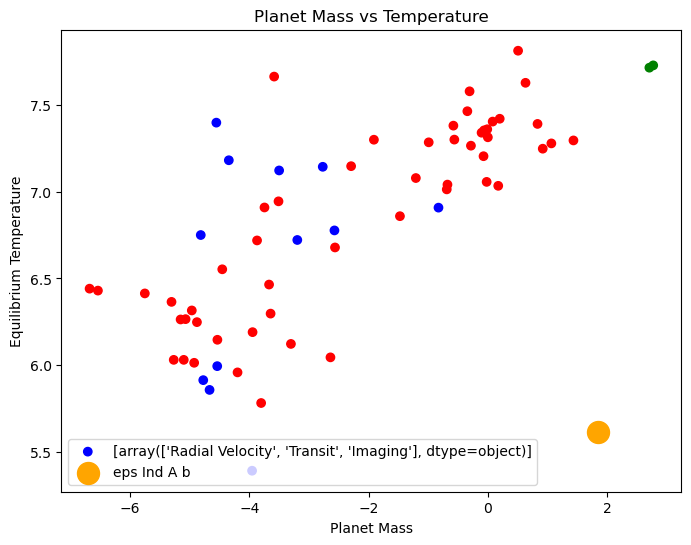

In [121]:
plt.figure(figsize = (8, 6))
methods = clean_df["discoverymethod"]
colormap = {"Transit": "r",
            "Radial Velocity": "b",
            "Imaging": "g"}
colors = [colormap[method] for method in methods]
labels = [clean_df["discoverymethod"].unique()]
plt.scatter(np.log(clean_df["pl_bmassj"]), np.log(clean_df["pl_eqt"]), c = colors, label = labels)
plt.xlabel("Planet Mass")
plt.ylabel("Equilibrium Temperature")
plt.title("Planet Mass vs Temperature")
plt.scatter(np.log(cold_info["pl_bmassj"]), np.log(cold_info["pl_eqt"]), c = "orange", s = 250, label = "eps Ind A b")
plt.legend()
plt.show()

In [122]:
# The paper is entitled "A temperate super-Jupiter imaged with JWST in the mid-infrared"

In [123]:
# My understanding of the abstract is that this planet eps Ind A b is surprisingly
# bright, given its cool temperature

In [124]:
# My answer does match the exoplanet!  eps Ind A b!

In [125]:
# This planet is special because it is far cooler than one would expect from its size
# and temperature

In [126]:
# The mass is consistent: 6.31 Jupiters
# The equilibrium temperature is consistent: 275 Kelvin